# Round 1 Data Analysis

This notebook contains exploratory data analysis for Round 1 of IMC Prosperity 4.

The products analysed in this round were ASH_COATED_OSMIUM and INTARIAN_PEPPER_ROOT.


## 1) Data loading

The Round 1 CSV files should be placed in the data/ folder.

Data files:

- prices_round_1_day_-2.csv 
- prices_round_1_day_-1.csv
- prices_round_1_day_0.csv
- trades_round_1_day_-2.csv
- trades_round_1_day_-1.csv
- trades_round_1_day_0.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("data")

In [4]:
df_prices0 = pd.read_csv(DATA_DIR / "prices_round_1_day_0.csv", sep=";")
df_prices1 = pd.read_csv(DATA_DIR / "prices_round_1_day_-1.csv", sep=";")
df_prices2 = pd.read_csv(DATA_DIR / "prices_round_1_day_-2.csv", sep=";")
df_trades0 = pd.read_csv(DATA_DIR / "trades_round_1_day_0.csv", sep=";")
df_trades1 = pd.read_csv(DATA_DIR / "trades_round_1_day_-1.csv", sep=";")
df_trades2 = pd.read_csv(DATA_DIR / "trades_round_1_day_-2.csv", sep=";")

print(df_prices1.columns)
print(df_trades1.columns)
print(df_prices0.shape)

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity'],
      dtype='object')
(20000, 17)


In [7]:
df_osmium0 = df_prices0[df_prices0["product"] == "ASH_COATED_OSMIUM"].copy()
df_osmium1 = df_prices1[df_prices1["product"] == "ASH_COATED_OSMIUM"].copy()
df_osmium2 = df_prices2[df_prices2["product"] == "ASH_COATED_OSMIUM"].copy()

df_root0 = df_prices0[df_prices0["product"] == "INTARIAN_PEPPER_ROOT"].copy()
df_root1 = df_prices1[df_prices1["product"] == "INTARIAN_PEPPER_ROOT"].copy()
df_root2 = df_prices2[df_prices2["product"] == "INTARIAN_PEPPER_ROOT"].copy()
print(df_osmium1.shape)
print(df_root1.shape)

(10000, 17)
(10000, 17)


## 2) Analysis and feature extraction: ``ASH_COATED_OSMIUM``

### 2.1) Mid-price behavior

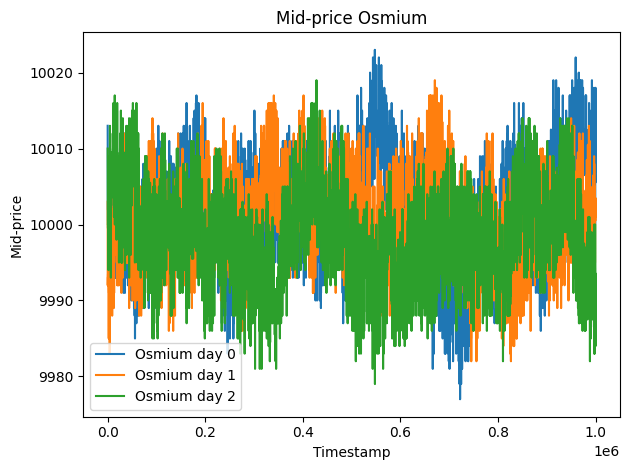

In [8]:
df_osmium0_clean = df_osmium0[df_osmium0["mid_price"] > 0].copy()
df_osmium1_clean = df_osmium1[df_osmium1["mid_price"] > 0].copy()
df_osmium2_clean = df_osmium2[df_osmium2["mid_price"] > 0].copy()

plt.plot(df_osmium0_clean["timestamp"], df_osmium0_clean["mid_price"], label="Osmium day 0")
plt.plot(df_osmium1_clean["timestamp"], df_osmium1_clean["mid_price"], label="Osmium day 1")
plt.plot(df_osmium2_clean["timestamp"], df_osmium2_clean["mid_price"], label="Osmium day 2")
plt.title("Mid-price Osmium")
plt.ylabel("Mid-price")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.legend()
plt.show()

The mid-price appears to fluctuate around a mean value, we could either perform a ensemble average or time average to get an estimate of the middle value.

Since we have only three days of data, a time average could better estimate the middle value.

In [ ]:
df_osmium0_new = df_osmium0_clean.copy()
df_osmium1_new = df_osmium1_clean.copy()
df_osmium2_new = df_osmium2_clean.copy()

df_osmium0_new["rolling_avg_10"] = df_osmium0_new["mid_price"].rolling(10).mean()
df_osmium1_new["rolling_avg_10"] = df_osmium1_new["mid_price"].rolling(10).mean()
df_osmium2_new["rolling_avg_10"] = df_osmium2_new["mid_price"].rolling(10).mean()

df_osmium0_new.dropna()
df_osmium1_new.dropna()
df_osmium2_new.dropna()

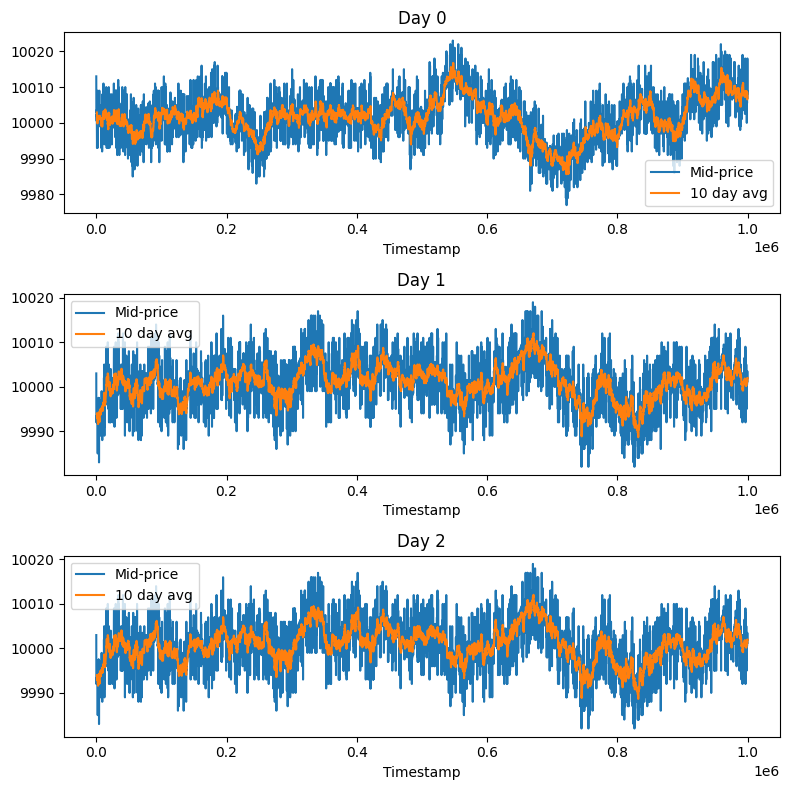

In [23]:
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize = (8,8))
ax1.plot(df_osmium0_new["timestamp"], df_osmium0_new["mid_price"], label="Mid-price")
ax1.plot(df_osmium0_new["timestamp"], df_osmium0_new["rolling_avg_10"], label="10 day avg")

ax2.plot(df_osmium1_new["timestamp"], df_osmium1_new["mid_price"], label="Mid-price")
ax2.plot(df_osmium1_new["timestamp"], df_osmium1_new["rolling_avg_10"], label="10 day avg")

ax3.plot(df_osmium1_new["timestamp"], df_osmium1_new["mid_price"], label="Mid-price")
ax3.plot(df_osmium1_new["timestamp"], df_osmium1_new["rolling_avg_10"], label="10 day avg")

ax1.set_xlabel("Timestamp")
ax2.set_xlabel("Timestamp")
ax3.set_xlabel("Timestamp")
ax1.legend()
ax2.legend()
ax3.legend()
ax1.set_title("Day 0")
ax2.set_title("Day 1")
ax3.set_title("Day 2")
plt.tight_layout()
plt.show()

### 2.2) Short-horizon movement check: should the strategy have mean reverting or momentum based trends?

In [28]:
for df in [df_osmium0, df_osmium1, df_osmium2]:
    df["mom_3"] = df["mid_price"] - df["mid_price"].shift(3)
    df["next_move"] = df["mid_price"].shift(-1) - df["mid_price"]

combined = pd.concat([df_osmium0, df_osmium1, df_osmium2], ignore_index=True)

print("mom_3 > 1.5  :", combined.loc[combined["mom_3"] > 1.5, "next_move"].mean())
print("mom_3 < -1.5 :", combined.loc[combined["mom_3"] < -1.5, "next_move"].mean())
print("|mom_3| <= 1:", combined.loc[combined["mom_3"].abs() <= 1, "next_move"].mean())
count_up = len(combined.loc[combined["mom_3"] > 1.5])
count_down = len(combined.loc[combined["mom_3"] < -1.5])
count_neutral = len(combined.loc[combined["mom_3"].abs() <= 1])

print(f"Count for mom_3 > 1.5: {count_up}")
print(f"Count for mom_3 < -1.5: {count_down}")
print(f"Count for |mom_3| <= 1: {count_neutral}")
print()
print("Interpretation: on average after a positive recent movement, the next move is negative and vice versa")

mom_3 > 1.5  : -20.87011557512383
mom_3 < -1.5 : 71.80808448652586
|mom_3| <= 1: -16.59799705087245
Count for mom_3 > 1.5: 5451
Count for mom_3 < -1.5: 5492
Count for |mom_3| <= 1: 16278

Interpretation: on average after a positive recent movement, the next move is negative and vice versa


### 2.3) Bid-ask prices

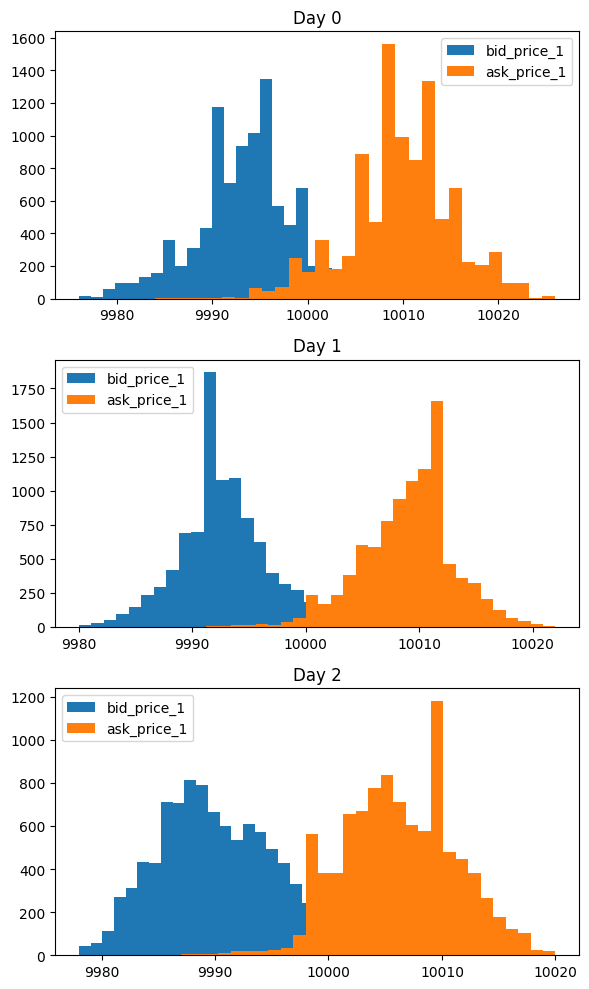

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (6,10))
ax1.hist(df_osmium0["bid_price_1"].values, bins = 30, label = "bid_price_1")
ax1.hist(df_osmium0["ask_price_1"].values, bins = 30, label = "ask_price_1")
ax2.hist(df_osmium1["bid_price_1"].values, bins = 30, label = "bid_price_1")
ax2.hist(df_osmium1["ask_price_1"].values, bins = 30, label = "ask_price_1")
ax3.hist(df_osmium2["bid_price_1"].values, bins = 30, label = "bid_price_1")
ax3.hist(df_osmium2["ask_price_1"].values, bins = 30, label = "ask_price_1")
ax1.legend()
ax2.legend()
ax3.legend()
ax1.set_title("Day 0")
ax2.set_title("Day 1")
ax3.set_title("Day 2")
plt.tight_layout()
plt.show()

### 2.4) Spread Histogram

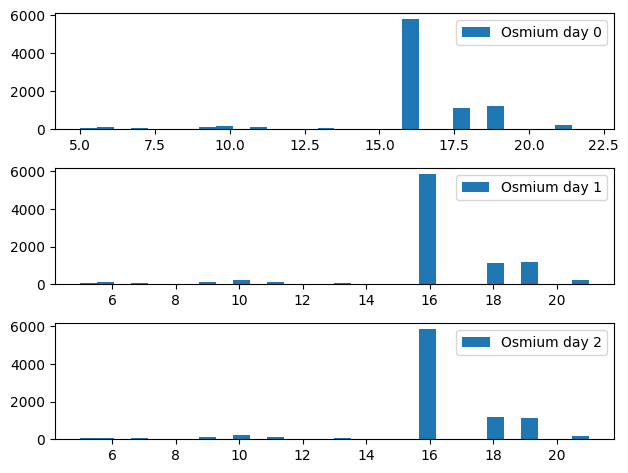

In [14]:
df_osmium0["spread"] = df_osmium0["ask_price_1"] - df_osmium0["bid_price_1"]
df_osmium1["spread"] = df_osmium1["ask_price_1"] - df_osmium1["bid_price_1"]
df_osmium2["spread"] = df_osmium2["ask_price_1"] - df_osmium2["bid_price_1"]

fig, (ax1, ax2, ax3) = plt.subplots(3,1)
ax1.hist(df_osmium0["spread"].values, bins = 30, label = "Osmium day 0")
ax2.hist(df_osmium1["spread"].values, bins = 30, label = "Osmium day 1")
ax3.hist(df_osmium2["spread"].values, bins = 30, label = "Osmium day 2")
ax1.legend()
ax2.legend()
ax3.legend()
plt.tight_layout()
plt.show()

### Summary: `ASH_COATED_OSMIUM`

From the feature analysis, we observe that:

- The mid price mostly fluctuates around `10000`, with raw values roughly in the range `9980–10020`.
- The 10-snapshot rolling average stays mostly around `9990–10010`, suggesting a local reference price rather than a strong trend.
- The best bid and ask distributions are concentrated on either side of `10000`, and the spread is most frequently around `16`, with smaller peaks around `18–19`.
- The short-horizon movement check suggests mean reversion: positive 3-snapshot moves are followed by negative next moves on average, while negative 3-snapshot moves are followed by positive next moves.
- Overall, `ASH_COATED_OSMIUM` looks suitable for local fair-value estimation, spread-aware quoting, and short-horizon mean-reversion strategies.

## 3) Analysis and feature extraction: ``INTARIAN_PEPPER_ROOT``

### 3.1) Mid-price

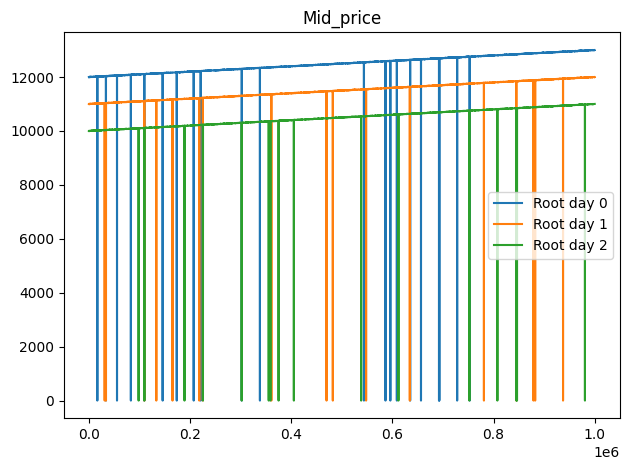

In [15]:
plt.plot(df_root0["timestamp"], df_root0["mid_price"],label = "Root day 0")
plt.plot(df_root1["timestamp"], df_root1["mid_price"],label = "Root day 1")
plt.plot(df_root2["timestamp"], df_root2["mid_price"],label = "Root day 2")
plt.title("Mid_price")
plt.legend()
plt.tight_layout()
plt.show()

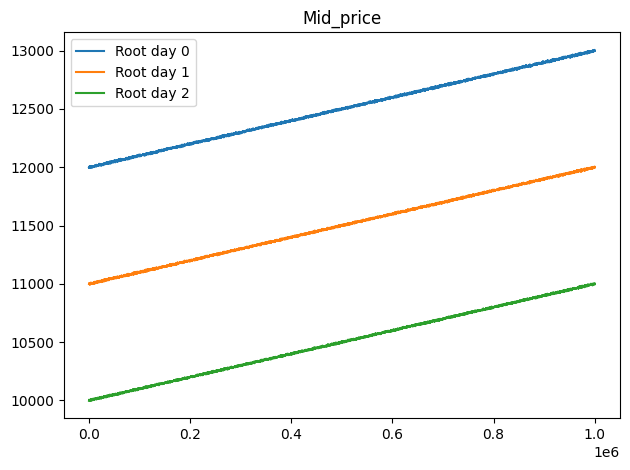

In [16]:
df_root0_clean = df_root0[df_root0["mid_price"] > 0].copy()
df_root1_clean = df_root1[df_root1["mid_price"] > 0].copy()
df_root2_clean = df_root2[df_root2["mid_price"] > 0].copy()

plt.plot(df_root0_clean["timestamp"], df_root0_clean["mid_price"], label="Root day 0")
plt.plot(df_root1_clean["timestamp"], df_root1_clean["mid_price"], label="Root day 1")
plt.plot(df_root2_clean["timestamp"], df_root2_clean["mid_price"], label="Root day 2")
plt.title("Mid_price")
plt.legend()
plt.tight_layout()
plt.show()

### 2.2) Spread histogram


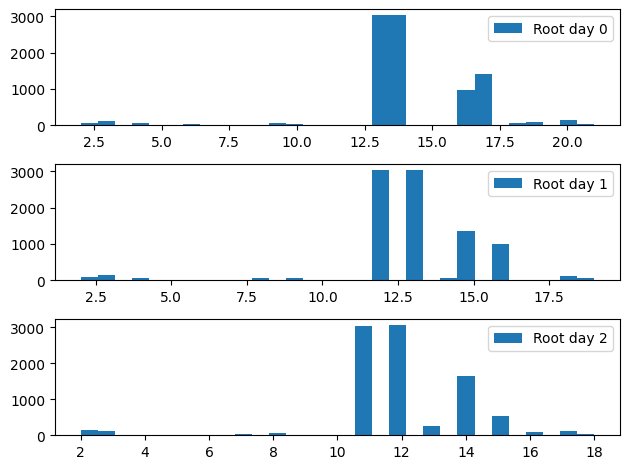

In [17]:
df_root0 = df_root0.copy()
df_root1 = df_root1.copy()
df_root2 = df_root2.copy()
df_root0["spread"] = df_root0["ask_price_1"] - df_root0["bid_price_1"]
df_root1["spread"] = df_root1["ask_price_1"] - df_root1["bid_price_1"]
df_root2["spread"] = df_root2["ask_price_1"] - df_root2["bid_price_1"]

fig, (ax1, ax2, ax3) = plt.subplots(3,1)
ax1.hist(df_root0["spread"].values, bins = 30, label = "Root day 0")
ax2.hist(df_root1["spread"].values, bins = 30, label = "Root day 1")
ax3.hist(df_root2["spread"].values, bins = 30, label = "Root day 2")
ax1.legend()
ax2.legend()
ax3.legend()
plt.tight_layout()
plt.show()


### Summary: `INTARIAN_PEPPER_ROOT`

From the feature analysis, we observe that:

- The mid price shows a strong upward trend on each provided day.
- The price increases by roughly `+1000` over each day: approximately `10000 → 11000`, `11000 → 12000`, and `12000 → 13000`.
- The three mid-price paths are almost parallel, suggesting a stable linear drift rather than noisy local fluctuation around a fixed level.
- The spread is most frequently concentrated around roughly `11–14`, with some secondary mass around `15–17`.
- Because the fair value clearly changes over time, a fixed fair-value strategy is not appropriate for this product.
- Overall, `INTARIAN_PEPPER_ROOT` looks suitable for a dynamic/drifting fair-value strategy, where the reference price is updated over time rather than held constant.